# Point Cloud Autoencoder

Here we create an autoencoder for pointclouds using the Observable and Chamfer losses.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms

The parameters for the experiment are here:

In [2]:
SEED = 0
DATA_ROOT = "./data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

#### Data Processing and Architecture Parameters
NUM_POINTS = 128
LATENT_DIM = 64
BATCH_SIZE = 128
NUM_EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-5
THRESHOLD = 0.25
NOISE_LEVEL = 0.5      
NOISE_STD = 1.0

### Parameters for the loss function
LAMBDA_CHAMFER = 1.0
LAMBDA_OBS = 0.0
NUM_OBS_ANCHORS = 128
NUM_OBSERVABLES = 64
NUM_FUNCTIONS_IN_OBSERVABLES = 1
ANCHOR_COVARIANCE_SCALE = 1.0

The main training pipeline is set up below.

In [3]:
# ============================================================
# Utilities
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def random_subsample_or_pad(X, num_points):
    n = X.shape[0]
    if n == num_points:
        return X
    if n > num_points:
        idx = torch.randperm(n)[:num_points]
        return X[idx]
    idx_extra = torch.randint(0, n, size=(num_points - n,))
    idx = torch.cat([torch.arange(n), idx_extra], dim=0)
    return X[idx]


def image_to_pointcloud(img, threshold=0.25, num_points=256):
    """
    Convert MNIST image to a 2D point cloud in [-1,1]^2.

    img is a PIL image or tensor-like object.
    """
    if not torch.is_tensor(img):
        img = transforms.ToTensor()(img)[0]

    mask = img > threshold
    coords = torch.nonzero(mask, as_tuple=False).float()  # rows, cols

    if coords.shape[0] == 0:
        coords = torch.tensor([[14.0, 14.0]])

    # Convert pixel coordinates to [-1,1]^2.
    # x = column, y = flipped row.
    y = coords[:, 0]
    x = coords[:, 1]

    x = x / 27.0 * 2.0 - 1.0
    y = 1.0 - y / 27.0 * 2.0

    X = torch.stack([x, y], dim=1)
    X = random_subsample_or_pad(X, num_points)
    return X.float()


def add_uniform_outliers(X, noise_level, num_points):
    """
    Add uniform outliers in [-1,1]^2, then resample back to num_points.
    """
    if noise_level <= 0:
        return X

    n_noise = int(round(noise_level * X.shape[0]))
    noise = 2.0 * torch.rand(n_noise, 2) - 1.0
    X_noisy = torch.cat([X, noise], dim=0)
    X_noisy = random_subsample_or_pad(X_noisy, num_points)
    return X_noisy.float()


# ============================================================
# Dataset
# ============================================================

class MNISTPointCloudDenoisingDataset(Dataset):
    def __init__(
        self,
        root="./data",
        train=True,
        download=True,
        threshold=0.25,
        num_points=256,
        noise_level=0.5,
    ):
        self.mnist = MNIST(
            root=root,
            train=train,
            download=download,
            transform=transforms.ToTensor(),
        )
        self.threshold = threshold
        self.num_points = num_points
        self.noise_level = noise_level

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, label = self.mnist[idx]
        img = img[0]

        clean = image_to_pointcloud(
            img,
            threshold=self.threshold,
            num_points=self.num_points,
        )

        noisy = add_uniform_outliers(
            clean,
            noise_level=self.noise_level,
            num_points=self.num_points,
        )

        return noisy, clean, label


# ============================================================
# Model
# ============================================================

class PointNetEncoder2D(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.pointwise = nn.Sequential(
            nn.Conv1d(2, 64, 1),
            nn.ReLU(),
            nn.Conv1d(64, 128, 1),
            nn.ReLU(),
            nn.Conv1d(128, 256, 1),
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        # x: (B,N,2)
        x = x.transpose(1, 2)
        h = self.pointwise(x)
        h = torch.max(h, dim=2).values
        z = self.fc(h)
        return z


class PointCloudDecoder2D(nn.Module):
    def __init__(self, latent_dim=64, num_points=256):
        super().__init__()
        self.num_points = num_points
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, num_points * 2),
        )

    def forward(self, z):
        out = self.net(z)
        return out.view(z.shape[0], self.num_points, 2)


class PointCloudAutoencoder2D(nn.Module):
    def __init__(self, latent_dim=64, num_points=256):
        super().__init__()
        self.encoder = PointNetEncoder2D(latent_dim)
        self.decoder = PointCloudDecoder2D(latent_dim, num_points)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


# ============================================================
# Losses
# ============================================================

def pairwise_squared_distances(X, Y):
    XX = (X ** 2).sum(dim=2, keepdim=True)
    YY = (Y ** 2).sum(dim=2, keepdim=True).transpose(1, 2)
    XY = torch.bmm(X, Y.transpose(1, 2))
    return torch.clamp(XX + YY - 2.0 * XY, min=0.0)


def chamfer_loss(X, Y):
    D2 = pairwise_squared_distances(X, Y)
    return D2.min(dim=2).values.mean() + D2.min(dim=1).values.mean()


class ObservableLoss2D(nn.Module):
    def __init__(
        self,
        num_anchors=128,
        num_observables=64,
        num_functions_in_observables=5,
        anchor_covariance_scale=1.0,
    ):
        super().__init__()

        anchors = math.sqrt(anchor_covariance_scale) * torch.randn(num_anchors, 2)
        self.register_buffer("anchors", anchors)

        subsets = []
        for _ in range(num_observables):
            idx = torch.randperm(num_anchors)[:num_functions_in_observables]
            subsets.append(idx)
        self.register_buffer("subsets", torch.stack(subsets, dim=0))

    def observable_values(self, X):
        B, N, _ = X.shape
        anchors = self.anchors.unsqueeze(0).expand(B, -1, -1)
        D = torch.cdist(X, anchors, p=2)
        selected = D[:, :, self.subsets]  # (B,N,L,m)
        vals = selected.min(dim=3).values
        return vals

    def forward(self, X, Y):
        vals_X = self.observable_values(X)
        vals_Y = self.observable_values(Y)

        vals_X, _ = torch.sort(vals_X, dim=1)
        vals_Y, _ = torch.sort(vals_Y, dim=1)

        return torch.abs(vals_X - vals_Y).mean()


# ============================================================
# Training / evaluation
# ============================================================

def train_one_epoch(model, loader, optimizer, obs_loss_fn, device):
    model.train()

    total_loss = 0.0
    total_ch = 0.0
    total_obs = 0.0
    total_count = 0

    for noisy, clean, _ in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()
        recon, _ = model(noisy)

        loss_ch = chamfer_loss(recon, clean)
        loss_obs = obs_loss_fn(recon, clean)
        loss = LAMBDA_CHAMFER * loss_ch + LAMBDA_OBS * loss_obs

        loss.backward()
        optimizer.step()

        b = noisy.shape[0]
        total_loss += loss.item() * b
        total_ch += loss_ch.item() * b
        total_obs += loss_obs.item() * b
        total_count += b

    return {
        "loss": total_loss / total_count,
        "chamfer": total_ch / total_count,
        "observable": total_obs / total_count,
    }


@torch.no_grad()
def evaluate(model, loader, obs_loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_ch = 0.0
    total_obs = 0.0
    total_count = 0

    for noisy, clean, _ in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        recon, _ = model(noisy)

        loss_ch = chamfer_loss(recon, clean)
        loss_obs = obs_loss_fn(recon, clean)
        loss = LAMBDA_CHAMFER * loss_ch + LAMBDA_OBS * loss_obs

        b = noisy.shape[0]
        total_loss += loss.item() * b
        total_ch += loss_ch.item() * b
        total_obs += loss_obs.item() * b
        total_count += b

    return {
        "loss": total_loss / total_count,
        "chamfer": total_ch / total_count,
        "observable": total_obs / total_count,
    }


# ============================================================
# Visualization
# ============================================================

@torch.no_grad()
def plot_reconstructions(model, dataset, device, indices=(0, 1, 2, 3), savepath=None):
    model.eval()

    fig, axes = plt.subplots(len(indices), 3, figsize=(9, 3 * len(indices)))

    if len(indices) == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        noisy, clean, label = dataset[idx]

        noisy_batch = noisy.unsqueeze(0).to(device)
        recon, _ = model(noisy_batch)
        recon = recon[0].cpu()

        panels = [
            (clean, f"Clean target: {label}"),
            (noisy, "Noisy input"),
            (recon, "Reconstruction"),
        ]

        for col, (X, title) in enumerate(panels):
            ax = axes[row, col]
            ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.8)
            ax.set_title(title)
            ax.set_xlim(-1.1, 1.1)
            ax.set_ylim(-1.1, 1.1)
            ax.set_aspect("equal")
            ax.axis("off")

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ============================================================
# Main experiment
# ============================================================

def run_mnist_pointcloud_denoising_experiment():
    set_seed(SEED)

    train_dataset = MNISTPointCloudDenoisingDataset(
        root=DATA_ROOT,
        train=True,
        download=True,
        threshold=THRESHOLD,
        num_points=NUM_POINTS,
        noise_level=NOISE_LEVEL,
    )

    test_dataset = MNISTPointCloudDenoisingDataset(
        root=DATA_ROOT,
        train=False,
        download=True,
        threshold=THRESHOLD,
        num_points=NUM_POINTS,
        noise_level=NOISE_LEVEL,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        drop_last=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        drop_last=False,
    )

    model = PointCloudAutoencoder2D(
        latent_dim=LATENT_DIM,
        num_points=NUM_POINTS,
    ).to(DEVICE)

    obs_loss_fn = ObservableLoss2D(
        num_anchors=NUM_OBS_ANCHORS,
        num_observables=NUM_OBSERVABLES,
        num_functions_in_observables=NUM_FUNCTIONS_IN_OBSERVABLES,
        anchor_covariance_scale=ANCHOR_COVARIANCE_SCALE,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    history = {
        "train_loss": [],
        "train_chamfer": [],
        "train_observable": [],
        "test_loss": [],
        "test_chamfer": [],
        "test_observable": [],
    }

    for epoch in range(1, NUM_EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, obs_loss_fn, DEVICE)
        test_metrics = evaluate(model, test_loader, obs_loss_fn, DEVICE)

        history["train_loss"].append(train_metrics["loss"])
        history["train_chamfer"].append(train_metrics["chamfer"])
        history["train_observable"].append(train_metrics["observable"])

        history["test_loss"].append(test_metrics["loss"])
        history["test_chamfer"].append(test_metrics["chamfer"])
        history["test_observable"].append(test_metrics["observable"])

        print(
            f"epoch {epoch:03d} | "
            f"train loss {train_metrics['loss']:.5f} "
            f"(ch={train_metrics['chamfer']:.5f}, obs={train_metrics['observable']:.5f}) | "
            f"test loss {test_metrics['loss']:.5f} "
            f"(ch={test_metrics['chamfer']:.5f}, obs={test_metrics['observable']:.5f})"
        )

        if epoch % 5 == 0 or epoch == 1:
            plot_reconstructions(
                model,
                test_dataset,
                DEVICE,
                indices=(0, 1, 2, 3),
                savepath=f"mnist_pointcloud_recon_epoch{epoch:03d}_Obs0_Chm1.png",
            )

    return {
        "model": model,
        "obs_loss_fn": obs_loss_fn,
        "history": history,
        "train_dataset": train_dataset,
        "test_dataset": test_dataset,
        "device": DEVICE,
    }

## Experiment

The following runs the experiment for the chosen parameters.

**Note:** The models used in the paper are saved in the `AutoencoderResults` folder. Subsequent analysis can be replicated on this saved data using the code below this.

In [4]:
results_mnist = run_mnist_pointcloud_denoising_experiment()

## Functions for Saving and Loading Results

In [5]:
def save_mnist_autoencoder(results_mnist, filepath):
    checkpoint = {
        "model_state_dict": results_mnist["model"].state_dict(),
        "history": results_mnist["history"],

        # store config explicitly (very important)
        "config": {
            "latent_dim": LATENT_DIM,
            "num_points": NUM_POINTS,
            "threshold": THRESHOLD,
            "noise_level": NOISE_LEVEL,
            "lambda_chamfer": LAMBDA_CHAMFER,
            "lambda_obs": LAMBDA_OBS,
            "num_obs_anchors": NUM_OBS_ANCHORS,
            "num_observables": NUM_OBSERVABLES,
            "num_functions_in_observables": NUM_FUNCTIONS_IN_OBSERVABLES,
        },
    }

    torch.save(checkpoint, filepath)
    print(f"Saved checkpoint to {filepath}")
    
def load_mnist_autoencoder(filepath, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    checkpoint = torch.load(filepath, map_location=device)

    cfg = checkpoint["config"]

    model = PointCloudAutoencoder2D(
        latent_dim=cfg["latent_dim"],
        num_points=cfg["num_points"],
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return {
        "model": model,
        "history": checkpoint["history"],
        "config": cfg,
        "device": device,
    }

## Latent Space Classification Analysis

The following uses a linear classifier in the latent spaces for the trained models.

In [18]:
import os
import pandas as pd
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


# ------------------------------------------------------------
# Model naming setup
# ------------------------------------------------------------

MODEL_DIR = "."

ALPHA_SPECS = [
    (0.00, "0",   "1",   "Chamfer"),
    (0.25, "p25", "p75", "alpha=0.25"),
    (0.50, "p5",  "p5",  "alpha=0.5"),
    (0.75, "p75", "p25", "alpha=0.75"),
    (1.00, "1",   "0",   "Observable"),
]

NOISE_SPECS = [
    (0.0, "0",  "clean"),
    (0.5, "p5", "noisy"),
]


def get_model_filename(noise_tag, obs_tag, ch_tag):
    return os.path.join(
        MODEL_DIR,
        f"mnist_denoising_autoencoder_noise_{noise_tag}_Obs_{obs_tag}_Ch_{ch_tag}.pt"
    )


# ------------------------------------------------------------
# Latent extraction
# ------------------------------------------------------------

@torch.no_grad()
def extract_latents_from_dataset(
    model,
    dataset,
    device,
    batch_size=256,
    use_noisy_input=False,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    model.eval()

    Z_list = []
    y_list = []

    for noisy, clean, labels in loader:
        x = noisy if use_noisy_input else clean
        x = x.to(device)

        _, z = model(x)

        Z_list.append(z.cpu().numpy())
        y_list.append(labels.numpy())

    Z = np.concatenate(Z_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    return Z, y


def latent_logreg_report(
    model,
    train_dataset,
    test_dataset,
    device,
    batch_size=256,
    use_noisy_input=False,
    max_iter=5000,
):
    Z_train, y_train = extract_latents_from_dataset(
        model,
        train_dataset,
        device,
        batch_size=batch_size,
        use_noisy_input=use_noisy_input,
    )

    Z_test, y_test = extract_latents_from_dataset(
        model,
        test_dataset,
        device,
        batch_size=batch_size,
        use_noisy_input=use_noisy_input,
    )

    clf = LogisticRegression(
        max_iter=max_iter,
        multi_class="auto",
    )

    clf.fit(Z_train, y_train)
    y_pred = clf.predict(Z_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_precision": report["weighted avg"]["precision"],
        "weighted_recall": report["weighted avg"]["recall"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "classifier": clf,
        "report": report,
    }


# ------------------------------------------------------------
# Main experiment over all saved models
# ------------------------------------------------------------

def run_latent_logreg_all_saved_models(
    model_dir=".",
    batch_size=256,
    max_iter=5000,
    device=None,
):
    global MODEL_DIR
    MODEL_DIR = model_dir

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    rows = []
    full_reports = {}

    for noise_level, noise_tag, noise_name in NOISE_SPECS:
        use_noisy_input = noise_level > 0

        for alpha, obs_tag, ch_tag, alpha_name in ALPHA_SPECS:
            filepath = get_model_filename(noise_tag, obs_tag, ch_tag)

            print(f"Loading {filepath}")

            loaded = load_mnist_autoencoder(filepath, device=device)
            model = loaded["model"]
            cfg = loaded["config"]

            train_dataset = MNISTPointCloudDenoisingDataset(
                root=DATA_ROOT,
                train=True,
                download=False,
                threshold=cfg["threshold"],
                num_points=cfg["num_points"],
                noise_level=noise_level,
            )

            test_dataset = MNISTPointCloudDenoisingDataset(
                root=DATA_ROOT,
                train=False,
                download=False,
                threshold=cfg["threshold"],
                num_points=cfg["num_points"],
                noise_level=noise_level,
            )

            metrics = latent_logreg_report(
                model=model,
                train_dataset=train_dataset,
                test_dataset=test_dataset,
                device=device,
                batch_size=batch_size,
                use_noisy_input=use_noisy_input,
                max_iter=max_iter,
            )

            row = {
                "noise": noise_name,
                "noise_level": noise_level,
                "alpha_observable": alpha,
                "alpha_chamfer": 1.0 - alpha,
                "model": alpha_name,
                "accuracy": metrics["accuracy"],
                "macro_precision": metrics["macro_precision"],
                "macro_recall": metrics["macro_recall"],
                "macro_f1": metrics["macro_f1"],
                "weighted_precision": metrics["weighted_precision"],
                "weighted_recall": metrics["weighted_recall"],
                "weighted_f1": metrics["weighted_f1"],
                "filepath": filepath,
            }

            rows.append(row)

            key = (noise_name, alpha)
            full_reports[key] = metrics["report"]

            print(
                f"{noise_name:5s} | {alpha_name:12s} | "
                f"accuracy={metrics['accuracy']:.4f} | "
                f"macro_f1={metrics['macro_f1']:.4f}"
            )

    df = pd.DataFrame(rows)
    return df, full_reports


# ------------------------------------------------------------
# Run
# ------------------------------------------------------------

latent_logreg_df, latent_full_reports = run_latent_logreg_all_saved_models(
    model_dir=".",
    batch_size=256,
    max_iter=5000,
)

latent_logreg_df

Loading ./mnist_denoising_autoencoder_noise_0_Obs_0_Ch_1.pt
clean | Chamfer      | accuracy=0.8731 | macro_f1=0.8718
Loading ./mnist_denoising_autoencoder_noise_0_Obs_p25_Ch_p75.pt
clean | alpha=0.25   | accuracy=0.8827 | macro_f1=0.8816
Loading ./mnist_denoising_autoencoder_noise_0_Obs_p5_Ch_p5.pt
clean | alpha=0.5    | accuracy=0.8878 | macro_f1=0.8867
Loading ./mnist_denoising_autoencoder_noise_0_Obs_p75_Ch_p25.pt
clean | alpha=0.75   | accuracy=0.8964 | macro_f1=0.8951
Loading ./mnist_denoising_autoencoder_noise_0_Obs_1_Ch_0.pt
clean | Observable   | accuracy=0.9092 | macro_f1=0.9082
Loading ./mnist_denoising_autoencoder_noise_p5_Obs_0_Ch_1.pt
noisy | Chamfer      | accuracy=0.7236 | macro_f1=0.7198
Loading ./mnist_denoising_autoencoder_noise_p5_Obs_p25_Ch_p75.pt
noisy | alpha=0.25   | accuracy=0.7374 | macro_f1=0.7335
Loading ./mnist_denoising_autoencoder_noise_p5_Obs_p5_Ch_p5.pt
noisy | alpha=0.5    | accuracy=0.7795 | macro_f1=0.7761
Loading ./mnist_denoising_autoencoder_noise_p

,noise,noise_level,alpha_observable,alpha_chamfer,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,filepath
0,clean,0.0,0.00,1.00,Chamfer,0.8731,0.872180,0.871777,0.871763,0.873229,0.8731,0.872951,./mnist_denoising_autoencoder_noise_0_Obs_0_Ch...
1,clean,0.0,0.25,0.75,alpha=0.25,0.8827,0.882169,0.881401,0.881589,0.882886,0.8827,0.882599,./mnist_denoising_autoencoder_noise_0_Obs_p25_...
2,clean,0.0,0.50,0.50,alpha=0.5,0.8878,0.887232,0.886532,0.886691,0.888224,0.8878,0.887823,./mnist_denoising_autoencoder_noise_0_Obs_p5_C...
3,clean,0.0,0.75,0.25,alpha=0.75,0.8964,0.895925,0.894840,0.895099,0.896869,0.8964,0.896360,./mnist_denoising_autoencoder_noise_0_Obs_p75_...
4,clean,0.0,1.00,0.00,Observable,0.9092,0.909015,0.907891,0.908165,0.909865,0.9092,0.909250,./mnist_denoising_autoencoder_noise_0_Obs_1_Ch...
5,noisy,0.5,0.00,1.00,Chamfer,0.7236,0.719973,0.720290,0.719843,0.722706,0.7236,0.722879,./mnist_denoising_autoencoder_noise_p5_Obs_0_C...
6,noisy,0.5,0.25,0.75,alpha=0.25,0.7374,0.734817,0.733627,0.733492,0.738822,0.7374,0.737374,./mnist_denoising_autoencoder_noise_p5_Obs_p25...
7,noisy,0.5,0.50,0.50,alpha=0.5,0.7795,0.777012,0.775856,0.776051,0.779702,0.7795,0.779238,./mnist_denoising_autoencoder_noise_p5_Obs_p5_...
8,noisy,0.5,0.75,0.25,alpha=0.75,0.7856,0.783805,0.782140,0.782487,0.786356,0.7856,0.785509,./mnist_denoising_autoencoder_noise_p5_Obs_p75...
9,noisy,0.5,1.00,0.00,Observable,0.8067,0.805646,0.803928,0.804277,0.807823,0.8067,0.806774,./mnist_denoising_autoencoder_noise_p5_Obs_1_C...


In [19]:
latent_logreg_df.to_csv("mnist_latent_logreg_macro_report.csv", index=False)

In [20]:
latent_logreg_df[
    [
        "noise",
        "model",
        "alpha_observable",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]
]

,noise,model,alpha_observable,accuracy,macro_precision,macro_recall,macro_f1
0,clean,Chamfer,0.00,0.8731,0.872180,0.871777,0.871763
1,clean,alpha=0.25,0.25,0.8827,0.882169,0.881401,0.881589
2,clean,alpha=0.5,0.50,0.8878,0.887232,0.886532,0.886691
3,clean,alpha=0.75,0.75,0.8964,0.895925,0.894840,0.895099
4,clean,Observable,1.00,0.9092,0.909015,0.907891,0.908165
5,noisy,Chamfer,0.00,0.7236,0.719973,0.720290,0.719843
6,noisy,alpha=0.25,0.25,0.7374,0.734817,0.733627,0.733492
7,noisy,alpha=0.5,0.50,0.7795,0.777012,0.775856,0.776051
8,noisy,alpha=0.75,0.75,0.7856,0.783805,0.782140,0.782487
9,noisy,Observable,1.00,0.8067,0.805646,0.803928,0.804277


## Visualizations

Here we provide various methods for visualizing the results. These functions generated the figures in the paper.

### Examples of Decodings

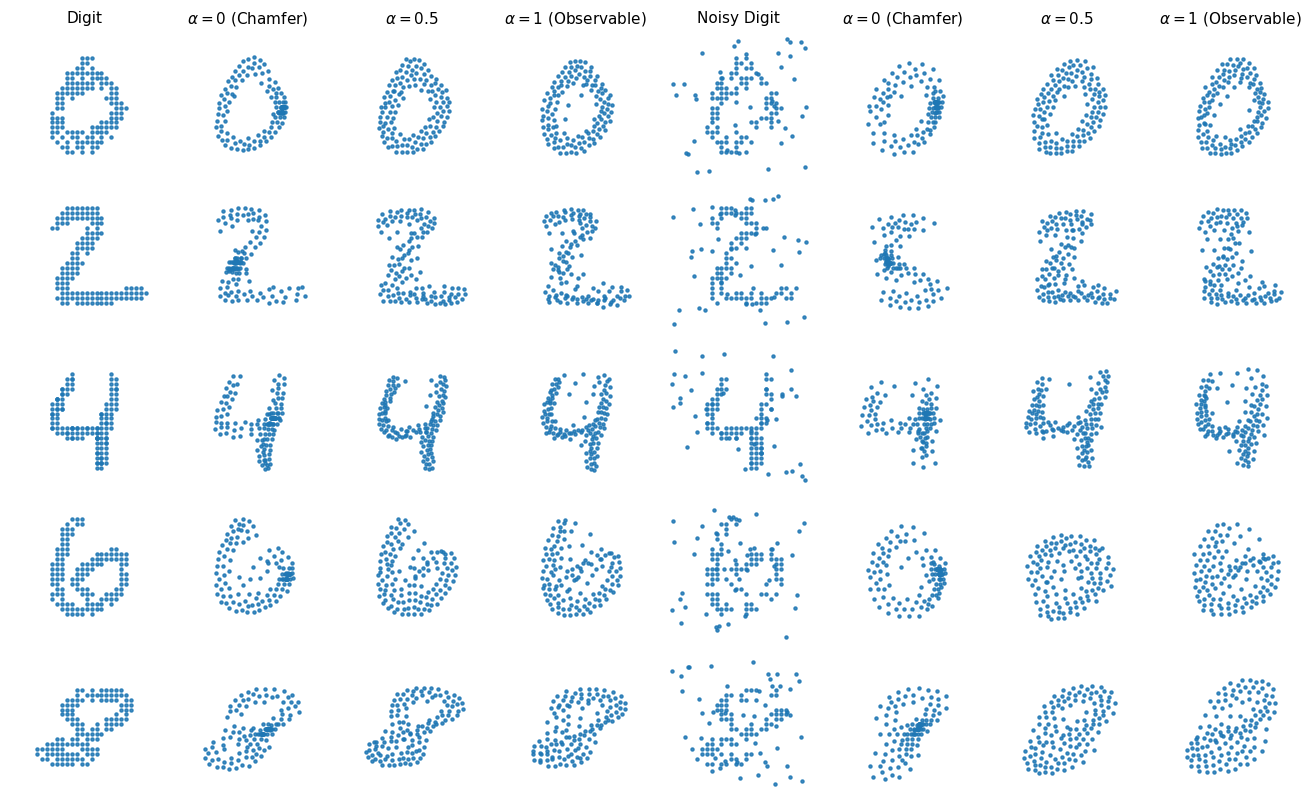

In [9]:
import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# User-facing plot choices
# ------------------------------------------------------------

MODEL_DIR = "./AutoencoderResults"  # change if needed

DIGITS_TO_PLOT = list([0,2,4,6,8])          # e.g. [0, 1, 4, 7]
ALPHAS_TO_PLOT = [0.0, 0.5, 1.0]

ALPHA_TO_TAGS = {
    0.0:  ("0",   "1"),
    0.25: ("p25", "p75"),
    0.5:  ("p5",  "p5"),
    0.75: ("p75", "p25"),
    1.0:  ("1",   "0"),
}

ALPHA_TO_LABEL = {
    0.0:  r"$\alpha = 0$ (Chamfer)",
    0.25: r"$\alpha = 0.25$",
    0.5:  r"$\alpha = 0.5$",
    0.75: r"$\alpha = 0.75$",
    1.0:  r"$\alpha = 1$ (Observable)",
}

NOISE_TO_TAG = {
    0.0: "0",
    0.5: "p5",
}


# ------------------------------------------------------------
# File naming
# ------------------------------------------------------------

def model_path(noise_level, alpha):
    obs_tag, ch_tag = ALPHA_TO_TAGS[alpha]
    noise_tag = NOISE_TO_TAG[noise_level]
    return f"{MODEL_DIR}/mnist_denoising_autoencoder_noise_{noise_tag}_Obs_{obs_tag}_Ch_{ch_tag}.pt"


# ------------------------------------------------------------
# Load only the requested models
# ------------------------------------------------------------

def load_model_set(noise_level, alphas, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    models = {}

    for alpha in alphas:
        path = model_path(noise_level, alpha)
        loaded = load_mnist_autoencoder(path, device=device)
        models[alpha] = loaded["model"]

    return models, device


models_clean, device = load_model_set(0.0, ALPHAS_TO_PLOT)
models_noisy, _ = load_model_set(0.5, ALPHAS_TO_PLOT, device=device)


# ------------------------------------------------------------
# Rebuild test datasets
# ------------------------------------------------------------

clean_test_dataset = MNISTPointCloudDenoisingDataset(
    root=DATA_ROOT,
    train=False,
    download=False,
    threshold=THRESHOLD,
    num_points=NUM_POINTS,
    noise_level=0.0,
)

noisy_test_dataset = MNISTPointCloudDenoisingDataset(
    root=DATA_ROOT,
    train=False,
    download=False,
    threshold=THRESHOLD,
    num_points=NUM_POINTS,
    noise_level=0.5,
)


# ------------------------------------------------------------
# Choose one example index per requested digit
# ------------------------------------------------------------

def get_first_index_for_each_digit(dataset, digits):
    digit_to_index = {}

    digits = [int(d) for d in digits]

    for idx in range(len(dataset)):
        _, _, label = dataset[idx]
        label = int(label)

        if label in digits and label not in digit_to_index:
            digit_to_index[label] = idx

        if len(digit_to_index) == len(digits):
            break

    missing = [d for d in digits if d not in digit_to_index]
    if missing:
        raise ValueError(f"Could not find examples for digits: {missing}")

    return [digit_to_index[d] for d in digits]


digit_indices = get_first_index_for_each_digit(clean_test_dataset, DIGITS_TO_PLOT)


# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------

def plot_cloud(ax, X, s=5):
    ax.scatter(X[:, 0], X[:, 1], s=s, alpha=0.85)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")


@torch.no_grad()
def reconstruct_cloud(model, X, device):
    model.eval()
    X_batch = X.unsqueeze(0).to(device)
    X_hat, _ = model(X_batch)
    return X_hat[0].cpu()


# ------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------

@torch.no_grad()
def plot_mnist_reconstruction_grid(
    clean_dataset,
    noisy_dataset,
    models_clean,
    models_noisy,
    digit_indices,
    alphas,
    device,
    figsize=None,
    point_size=5,
    savepath=None,
):
    num_rows = len(digit_indices)
    num_alpha = len(alphas)
    num_cols = 2 + 2 * num_alpha

    if figsize is None:
        figsize = (2.1 * num_cols, 2.0 * num_rows)

    col_titles = (
        ["Digit"]
        + [ALPHA_TO_LABEL[a] for a in alphas]
        + ["Noisy Digit"]
        + [ALPHA_TO_LABEL[a] for a in alphas]
    )

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    if num_rows == 1:
        axes = axes[None, :]

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11)

    for row, idx in enumerate(digit_indices):
        _, clean, _ = clean_dataset[idx]
        noisy_input, _, _ = noisy_dataset[idx]

        plot_cloud(axes[row, 0], clean, s=point_size)

        for j, alpha in enumerate(alphas):
            recon = reconstruct_cloud(models_clean[alpha], clean, device)
            plot_cloud(axes[row, 1 + j], recon, s=point_size)

        noisy_col = 1 + num_alpha
        plot_cloud(axes[row, noisy_col], noisy_input, s=point_size)

        for j, alpha in enumerate(alphas):
            recon = reconstruct_cloud(models_noisy[alpha], noisy_input, device)
            plot_cloud(axes[row, noisy_col + 1 + j], recon, s=point_size)

    plt.subplots_adjust(wspace=0.05, hspace=0.05)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


plot_mnist_reconstruction_grid(
    clean_dataset=clean_test_dataset,
    noisy_dataset=noisy_test_dataset,
    models_clean=models_clean,
    models_noisy=models_noisy,
    digit_indices=digit_indices,
    alphas=ALPHAS_TO_PLOT,
    device=device,
    point_size=5,
    savepath="mnist_reconstruction_grid_custom.png",
)

### Latent Space Averages

Here we plot averages of each digit class, where the average is taken in the latent space and decoded by each model.

In [10]:
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def latent_average_digit(model, dataset, digit, device, use_noisy_input=False):
    model.eval()

    Z = []

    for idx in range(len(dataset)):
        noisy, clean, label = dataset[idx]
        if int(label) != digit:
            continue

        x = noisy if use_noisy_input else clean
        x = x.unsqueeze(0).to(device)

        _, z = model(x)
        Z.append(z[0].cpu())

    Z = torch.stack(Z, dim=0)
    z_mean = Z.mean(dim=0).to(device)

    avg_recon = model.decoder(z_mean.unsqueeze(0))[0].cpu()

    return avg_recon


def plot_two_row_average_digits(
    model_obs,
    model_ch,
    dataset,
    device,
    use_noisy_input=False,
    figsize=(18, 4),
    point_size=6,
    savepath=None,
):
    fig, axes = plt.subplots(2, 10, figsize=figsize)

    for digit in range(10):
        # Row 1: Observable
        avg_obs = latent_average_digit(
            model_obs, dataset, digit, device, use_noisy_input
        )

        axes[0, digit].scatter(
            avg_obs[:, 0], avg_obs[:, 1],
            s=point_size, alpha=0.85
        )

        # Row 2: Chamfer
        avg_ch = latent_average_digit(
            model_ch, dataset, digit, device, use_noisy_input
        )

        axes[1, digit].scatter(
            avg_ch[:, 0], avg_ch[:, 1],
            s=point_size, alpha=0.85
        )

        # Formatting
        for row in [0, 1]:
            ax = axes[row, digit]
            ax.set_xlim(-1.1, 1.1)
            ax.set_ylim(-1.1, 1.1)
            ax.set_aspect("equal")
            ax.axis("off")

    # ---- Add row labels on the left ----
    fig.text(
        0.02, 0.75, "Observable",
        va="center", ha="left",
        rotation=90,
        fontsize=14
    )

    fig.text(
        0.02, 0.25, "Chamfer",
        va="center", ha="left",
        rotation=90,
        fontsize=14
    )

    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.08)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

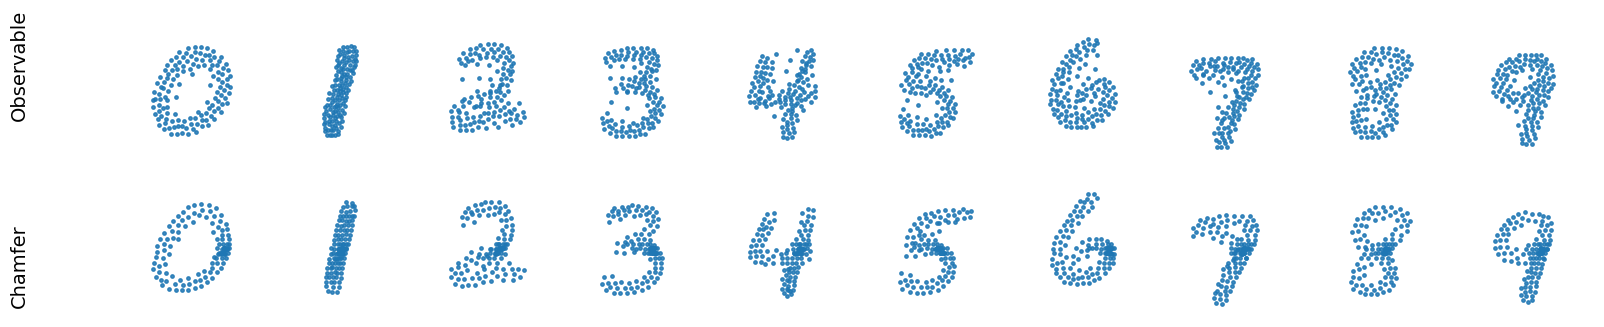

In [11]:
# Pure Observable (alpha = 1)
loaded_obs = load_mnist_autoencoder(
    "mnist_denoising_autoencoder_noise_0_Obs_1_Ch_0.pt"
)

# Pure Chamfer (alpha = 0)
loaded_ch = load_mnist_autoencoder(
    "mnist_denoising_autoencoder_noise_0_Obs_0_Ch_1.pt"
)

model_obs = loaded_obs["model"]
model_ch = loaded_ch["model"]
device = loaded_obs["device"]
cfg = loaded_obs["config"]

clean_test_dataset = MNISTPointCloudDenoisingDataset(
    root=DATA_ROOT,
    train=False,
    download=False,
    threshold=cfg["threshold"],
    num_points=cfg["num_points"],
    noise_level=0.0,
)

plot_two_row_average_digits(
    model_obs=model_obs,
    model_ch=model_ch,
    dataset=clean_test_dataset,
    device=device,
    use_noisy_input=False,
    savepath="avg_digits_clean.png",
)

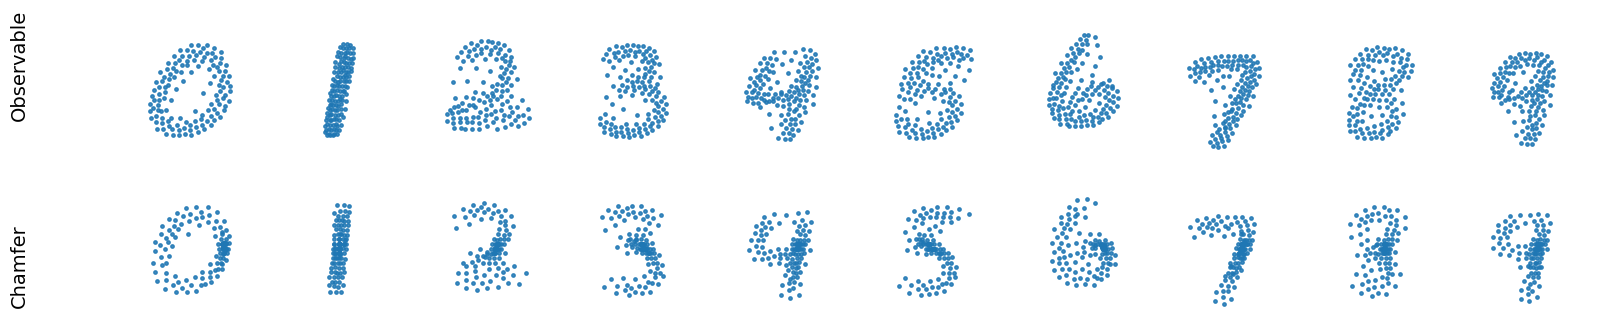

In [13]:
# Pure Observable denoising model
loaded_obs_noisy = load_mnist_autoencoder(
    "mnist_denoising_autoencoder_noise_p5_Obs_1_Ch_0.pt"
)

# Pure Chamfer denoising model
loaded_ch_noisy = load_mnist_autoencoder(
    "mnist_denoising_autoencoder_noise_p5_Obs_0_Ch_1.pt"
)

model_obs_noisy = loaded_obs_noisy["model"]
model_ch_noisy = loaded_ch_noisy["model"]
device_noisy = loaded_obs_noisy["device"]
cfg_noisy = loaded_obs_noisy["config"]

noisy_test_dataset = MNISTPointCloudDenoisingDataset(
    root=DATA_ROOT,
    train=False,
    download=False,
    threshold=cfg_noisy["threshold"],
    num_points=cfg_noisy["num_points"],
    noise_level=0.5,
)

plot_two_row_average_digits(
    model_obs=model_obs_noisy,
    model_ch=model_ch_noisy,
    dataset=noisy_test_dataset,
    device=device_noisy,
    use_noisy_input=True,
    savepath="avg_digits_noisy_using_denoising_models.png",
)

## Interpolations

The following interpolates between digit averages in the latent space and decodes along the interpolation.

In [14]:
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def class_mean_latent(model, dataset, digit, device, use_noisy_input=False):
    model.eval()
    Z = []

    for idx in range(len(dataset)):
        noisy, clean, label = dataset[idx]
        if int(label) != int(digit):
            continue

        x = noisy if use_noisy_input else clean
        x = x.unsqueeze(0).to(device)

        _, z = model(x)
        Z.append(z[0].cpu())

    if len(Z) == 0:
        raise ValueError(f"No examples found for digit {digit}")

    Z = torch.stack(Z, dim=0)
    return Z.mean(dim=0).to(device)


@torch.no_grad()
def decode_latent_interpolation(
    model,
    z_a,
    z_b,
    t_values,
):
    model.eval()

    decoded = []

    for t in t_values:
        z_t = (1.0 - t) * z_a + t * z_b
        X_t = model.decoder(z_t.unsqueeze(0))[0].cpu()
        decoded.append(X_t)

    return decoded


def plot_latent_digit_morph(
    model,
    dataset,
    digit_a,
    digit_b,
    device,
    t_values=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5 ,0.6, 0.7, 0.8, 0.9, 1.0),
    use_noisy_input=False,
    figsize=(24, 3),
    point_size=8,
    savepath=None,
):
    z_a = class_mean_latent(
        model=model,
        dataset=dataset,
        digit=digit_a,
        device=device,
        use_noisy_input=use_noisy_input,
    )

    z_b = class_mean_latent(
        model=model,
        dataset=dataset,
        digit=digit_b,
        device=device,
        use_noisy_input=use_noisy_input,
    )

    clouds = decode_latent_interpolation(
        model=model,
        z_a=z_a,
        z_b=z_b,
        t_values=t_values,
    )

    fig, axes = plt.subplots(1, len(t_values), figsize=figsize)

    if len(t_values) == 1:
        axes = [axes]

    for ax, X, t in zip(axes, clouds, t_values):
        ax.scatter(X[:, 0], X[:, 1], s=point_size, alpha=0.85)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.set_aspect("equal")
        ax.axis("off")

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

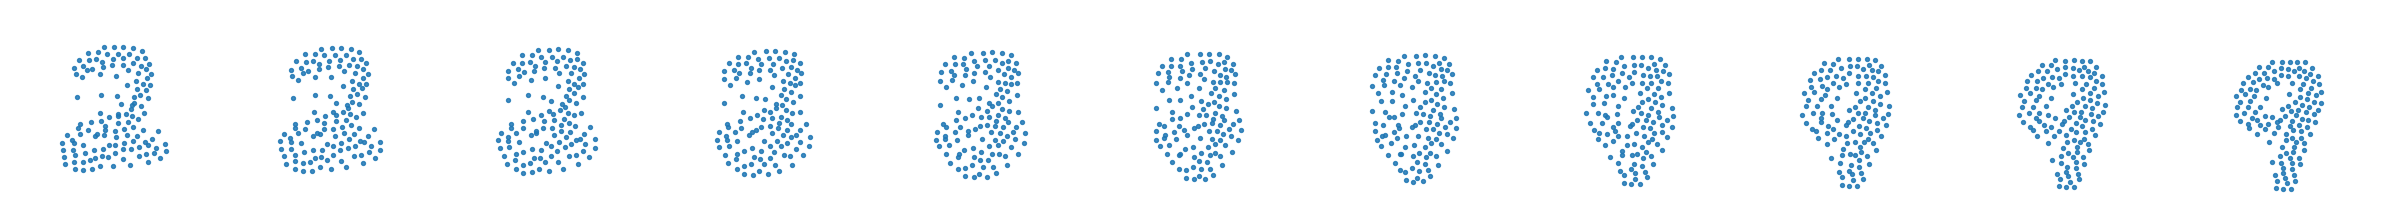

In [17]:
loaded_obs_clean = load_mnist_autoencoder(
    "mnist_denoising_autoencoder_noise_0_Obs_1_Ch_0.pt"
)

model_obs_clean = loaded_obs_clean["model"]
device = loaded_obs_clean["device"]
cfg = loaded_obs_clean["config"]

clean_test_dataset = MNISTPointCloudDenoisingDataset(
    root=DATA_ROOT,
    train=False,
    download=False,
    threshold=cfg["threshold"],
    num_points=cfg["num_points"],
    noise_level=0.0,
)

plot_latent_digit_morph(
    model=model_obs_clean,
    dataset=clean_test_dataset,
    digit_a=2,
    digit_b=9,
    device=device,
    t_values=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5 ,0.6, 0.7, 0.8, 0.9, 1.0),
    use_noisy_input=False,
    savepath="latent_morph_3_to_9_observable.png",
)